# Queue Simulation: Waiting, Congestion, and Blocking

Author: Fred J. Hickernell

How long will a customer wait, and what makes a queue grow? We build two models:
a single service window and a drive-through with an order window followed by a
pickup window. Random arrival and service times generate a random history;
we summarize that history using customer delays and time spent congested.

These are **event-driven simulations of a physical system**, not
Metropolis–Hastings algorithms. Both belong in our Markov-chain discussion,
but queue customers are not posterior samples and there is no acceptance ratio.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/fjhickernell/MATH565Fall2026/blob/main/notebooks/applications/QueueSimulation.ipynb)

Run all cells in order with the local `qmcpy` kernel or a private Colab copy.
For local use, install the additional dependency once in that environment:
`python -m pip install "simpy>=4.1.2"`. The Colab setup installs it automatically,
along with the course's recorded dependencies. Keep the complete course checkout,
including [the queue model helper](../queue_examples.py).

In [1]:
from pathlib import Path
import shutil
import subprocess
import sys
import time

NOTEBOOK_START_TIME = time.perf_counter()

colab = "google.colab" in sys.modules
if colab:
    print("Setting up this course's recorded classlib, QMCPy, and TeX; this may take several minutes …")
    course_checkout = Path("/content/MATH565Fall2026")
    if not course_checkout.exists():
        subprocess.run(
            [
                "git", "clone", "--quiet", "--depth", "1",
                "https://github.com/fjhickernell/MATH565Fall2026.git",
                str(course_checkout),
            ],
            check=True,
        )
    subprocess.run(
        [
            "git", "-C", str(course_checkout),
            "-c", "submodule.classlib.url=https://github.com/fjhickernell/HickernellAcademicLib.git",
            "-c", "submodule.qmcpy.url=https://github.com/QMCSoftware/qmcpy.git",
            "submodule", "update", "--init", "classlib", "qmcpy",
        ],
        check=True,
    )
    if shutil.which("latex") is None:
        subprocess.run(
            [
                "apt-get", "-qq", "install", "-y",
                "cm-super", "dvipng", "texlive-latex-extra",
                "texlive-latex-recommended",
            ],
            check=True,
        )
    subprocess.run(
        [
            sys.executable, "-m", "pip", "install", "-q",
            str(course_checkout / "classlib"),
            str(course_checkout / "qmcpy"),
            "simpy>=4.1.2",
        ],
        check=True,
    )
    print("Colab setup complete.")
    print("For faster repeated work, use the local `qmcpy` environment.")

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
import simpy
import classlib as cl

%matplotlib inline
cl.nbviz.init(use_tex=True)
colors = cl.nbviz.TOL_BRIGHT
rng = np.random.default_rng()  # Fresh realizations on each run.
search_roots = ([course_checkout] if colab else []) + [Path.cwd(), *Path.cwd().parents]
notebook_dir = next((p / 'notebooks' for p in search_roots
                     if (p / 'notebooks' / 'queue_examples.py').is_file()), None)
if notebook_dir is None:
    raise FileNotFoundError('Open this notebook inside the complete MATH565Fall2026 checkout')
sys.path.insert(0, str(notebook_dir))
from queue_examples import simulate_queue
print(f'SimPy {simpy.__version__}')

def show_metrics(metrics, fields):
    rows = ['| Quantity | Value |', '|:---|---:|']
    for key, label in fields:
        value = metrics[key]
        formatted = str(value) if isinstance(value, (int, np.integer)) else f'{value:.4f}'
        rows.append(f'| {label} | {formatted} |')
    display(Markdown('\n'.join(rows)))

SimPy 4.1.2


## A single-server queue

### Model and state

Customers arrive independently with exponential interarrival times of mean
$1/\lambda$; their service times are independent and uniform on $[a,b]$.
One server handles customers in first-come, first-served order. Time is measured
in minutes. In standard queueing notation this is an **M/U/1** queue: memoryless
interarrivals, uniform service, and one server.

Write $U_k$ for the $k$th full interarrival duration and $V_j$ for customer
$j$'s full service duration. Let $V$ denote a generic service-time random
variable, and let $S(t)$ denote the remaining service time. Then
\begin{align*}
\mathbb E[V]&=(a+b)/2, &
\mathbb E[V^2]&=(a^2+ab+b^2)/3, &
r&=\lambda\mathbb E[V].
\end{align*}
To match the slides, let $T_i$ be the $i$th event time and view the state
immediately afterward:
\begin{align*}
A_i&=\text{time from $T_i$ to the next arrival}, &
N_i&=N(T_i^+), &
S_i&=S(T_i^+).
\end{align*}
After the $k$th arrival, reset $A_{i+1}=U_{k+1}$. When customer $j$ begins
service, reset $S_{i+1}=V_j$. At those reset instants the clocks contain full
input durations. Between events, $A_i$ and $S_i$ are residual times that count
down. Thus $S_i$ is the unfinished portion of the current service. For
customer $j$, let $a_j$, $b_j$,
and $d_j$ denote the arrival, service-start, and departure times. Then
$W_j=d_j-a_j$ is total time in the system, while
$W_{q,j}=b_j-a_j$ is queue-only waiting time.

The **traffic intensity** $r$ is the workload arriving per unit time. For this
model, $r<1$ is the condition for a stationary queue-length distribution; as
$r$ approaches 1, long queues become more common. We use $r$ to avoid confusing
traffic intensity with the course's correlation symbol $\rho$.

Uniform service is not memoryless: $N(t)$ alone does not determine the law of
the next departure. Include the residual service time, and, when working with
scheduled events, the time to the next arrival. Idle servers have no pending
service completion. Future independent draws and the current state determine
the next-state law.

<div class="highlight-note"><strong>Remember the residual time.</strong> Queue length alone is not enough when service is not memoryless.</div>

### How the event code works

[SimPy](https://simpy.readthedocs.io/en/stable/simpy_intro/shared_resources.html)
advances time to the next event. A customer's process requests the server,
waits for its turn, spends its service time there, then releases the server:

```python
with server.request() as request:
    yield request
    yield env.timeout(service_time)
```

`yield` pauses this customer's process while other customers and events proceed.
The `with` block releases the server automatically. Our helper adds timestamps
for arrival epochs, service starts, and departures. The code stores absolute
full interarrival durations in `interarrival_times`, then takes their cumulative sum
to obtain the absolute epochs in `arrival_times`. It stores the $V_j$ service
durations in `service_times` so implementations or capacities can use identical
inputs, but a duration enters the event calendar
only when that customer begins service.

| Quantity | Value |
|:---|---:|
| Simulated horizon, $T_{\max}$ (minutes) | 2000.0000 |
| Arrivals | 1556 |
| Departures | 1554 |
| Customers still present | 2 |
| Observed arrivals per minute | 0.7780 |
| Time-average number in system | 1.9644 |
| Mean queue wait among departed customers | 1.5247 |
| Mean total time among departed customers | 2.5261 |
| Fraction of time serving | 0.7781 |

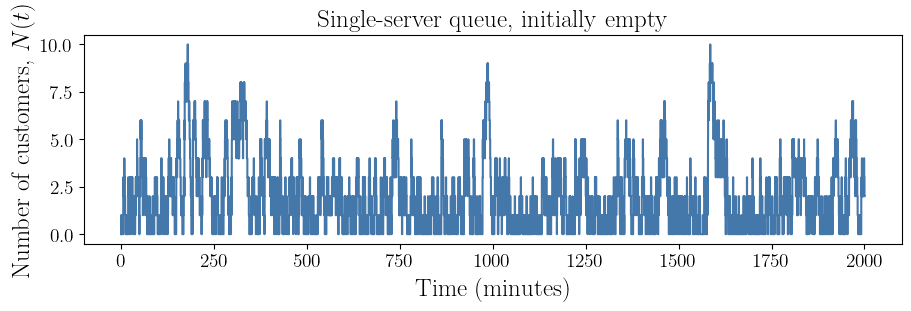

In [3]:
arrival_rate = 0.8
service_a, service_b = 0.8, 1.2
t_end = 2000.0
n_inputs = 5000
interarrival_times = rng.exponential(1 / arrival_rate, n_inputs)
arrival_times = np.cumsum(interarrival_times)
service_times = rng.uniform(service_a, service_b, n_inputs)
assert arrival_times[-1] > t_end, 'Increase n_inputs to cover the whole arrival horizon'
run = simulate_queue(arrival_times, service_times, t_end=t_end)
metrics = run.summary()
show_metrics(metrics, [
    ('sim_time', r'Simulated horizon, $T_{\max}$ (minutes)'), ('arrivals', 'Arrivals'),
    ('departures', 'Departures'), ('remaining', 'Customers still present'),
    ('arrival_rate', 'Observed arrivals per minute'),
    ('avg_N', 'Time-average number in system'),
    ('avg_wait_1', 'Mean queue wait among departed customers'),
    ('avg_W', 'Mean total time among departed customers'),
    ('busy_1', 'Fraction of time serving'),
])
fig, ax = plt.subplots(figsize=(9, 3), constrained_layout=True)
times, counts = run.trajectory()
ax.step(times, counts, where='post')
ax.set(xlabel='Time (minutes)', ylabel=r'Number of customers, $N(t)$', title='Single-server queue, initially empty')
plt.show()

### Interpreting a finite run

`avg_N` averages over **time** and includes every customer present, waiting or
being served. `avg_W` and `avg_wait_1` average over **customers who have departed**.
Customers still present at the stopping time have incomplete delays, so excluding
them can favor shorter completed delays. The run also starts empty rather than
in stationarity. A longer run helps assess these boundary effects; one path is
not an error bar.

<div class="highlight-note"><strong>Two averages, two questions.</strong> Time averages measure congestion; completed-customer averages measure delay and can omit the longest unfinished waits.</div>

The helper stops at time `t_end`, after `n_complete` departures, or at whichever
condition occurs first. Time-limited runs exclude events scheduled exactly at
`t_end`. Departure-limited runs include the departure that reaches the target.
Service and residence times are clipped at the stopping time for time averages;
future service is never counted as work already performed.

Little's law, $L=\lambda W$, relates long-run averages under suitable steady-state
conditions. The following **finite-run accounting identity** is exact for a
system initially empty:
\begin{align*}
\frac1{T_{\max}}\int_0^{T_{\max}} N(t)\,\mathrm dt
&=\frac1{T_{\max}}\sum_{j:\,d_j\leq T_{\max}}(d_j-a_j)
 +\frac1{T_{\max}}\sum_{j:\,a_j<T_{\max}<d_j}(T_{\max}-a_j).
\end{align*}
Here $a_j$ and $d_j$ denote arrival and departure times; the second sum includes
unfinished customers. A departure exactly at a time cutoff is treated as
unfinished by our stopping convention, with the same residence contribution.
The first term is departure rate times the mean completed delay. The second
term explains why that product alone need not equal the time-average population.

In [4]:
completed_part = metrics['completed_residence_per_time']
unfinished_part = metrics['unfinished_residence_per_time']
display(Markdown(
    f"Time-average population **{metrics['avg_N']:.4f}** = "
    f"completed-customer contribution **{completed_part:.4f}** + "
    f"unfinished-customer contribution **{unfinished_part:.4f}**."))
assert np.isclose(metrics['avg_N'], completed_part + unfinished_part)
# Independent integration of the plotted step function checks the bookkeeping.
assert np.isclose(np.sum(np.diff(times) * counts[:-1]) / run.time, metrics['avg_N'])

# The same inputs can instead stop after a requested number of departures.
by_departures = simulate_queue(arrival_times, service_times, n_complete=1000)
assert by_departures.summary()['departures'] == 1000
print(f'1000 departures occur by time {by_departures.time:.2f} minutes.')

Time-average population **1.9644** = completed-customer contribution **1.9628** + unfinished-customer contribution **0.0017**.

1000 departures occur by time 1267.04 minutes.


### A numerical benchmark and independent replications

For an M/G/1 queue with independent service times and $r<1$, the stationary
mean wait in queue is
\begin{align*}
W_q&=\frac{\lambda\mathbb E[V^2]}{2(1-r)}, &
W&=W_q+\mathbb E[V], & L&=\lambda W.
\end{align*}
This is the [Pollaczek–Khinchin formula](https://web.mit.edu/dimitrib/www/Queueing_Data_Nets.pdf)
(Section 3.5). It gives a check on the simulation, not an exact prediction for each finite
run. Below, each dot comes from an independent run starting empty. Their spread
shows sampling variability; their average may still have startup and stopping
bias. Increase `replication_horizon` to examine that bias. Within-run customer
delays are dependent, so treating them as IID would give misleading error bars.

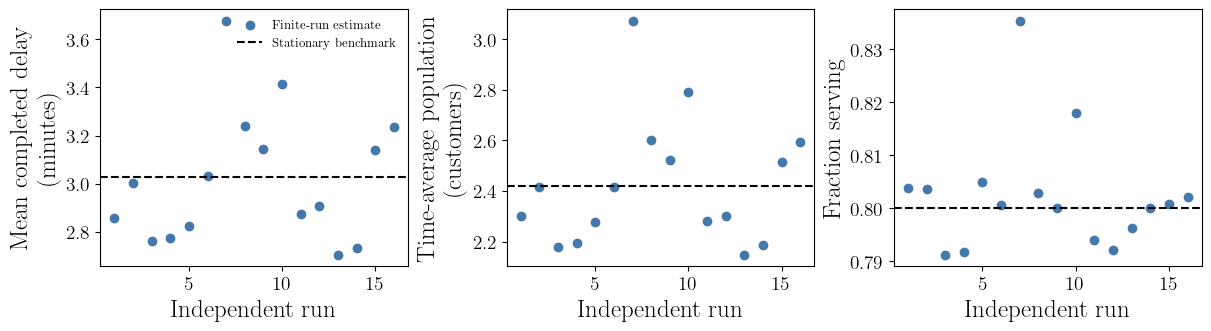

Stationary benchmarks: $W_q=2.027$ min, $W=3.027$ min, $L=2.421$, $r=0.800$.

In [5]:
mean_service = (service_a + service_b) / 2
second_moment = (service_a**2 + service_a * service_b + service_b**2) / 3
traffic = arrival_rate * mean_service
assert traffic < 1
exact_wait = arrival_rate * second_moment / (2 * (1 - traffic))
exact_time = exact_wait + mean_service
replication_horizon = 5000.0
replications = 16
values = []
for _ in range(replications):
    interarrival_times_rep = rng.exponential(1 / arrival_rate, 10000)
    arrival_times_rep = np.cumsum(interarrival_times_rep)
    service_times_rep = rng.uniform(service_a, service_b, len(arrival_times_rep))
    assert arrival_times_rep[-1] > replication_horizon, 'Increase the number of input customers'
    result = simulate_queue(arrival_times_rep, service_times_rep, t_end=replication_horizon).summary()
    values.append([result['avg_W'], result['avg_N'], result['busy_1']])
values = np.asarray(values)
benchmarks = [exact_time, arrival_rate * exact_time, traffic]
fig, axes = plt.subplots(1, 3, figsize=(12, 3.2), constrained_layout=True)
for k, (ax, label, benchmark) in enumerate(zip(
        axes, ['Mean completed delay\n(minutes)', 'Time-average population\n(customers)', 'Fraction serving'], benchmarks)):
    ax.plot(np.arange(1, replications + 1), values[:, k], 'o', label='Finite-run estimate')
    ax.axhline(benchmark, color='black', linestyle='--', label='Stationary benchmark')
    ax.set(xlabel='Independent run', ylabel=label)
axes[0].legend(fontsize=9)
plt.show()
display(Markdown(f'Stationary benchmarks: $W_q={exact_wait:.3f}$ min, '
                 f'$W={exact_time:.3f}$ min, $L={arrival_rate * exact_time:.3f}$, '
                 f'$r={traffic:.3f}$.'))

## A drive-through with downstream blocking

### Two windows and a finite pickup lane

Every car first orders, then collects its order. Each window serves one car at
a time in first-come, first-served order. Interarrival times are exponential;
service times at the two windows are independent uniforms.

The pickup capacity `capacity` counts **both waiting cars and the car being
served at pickup**. A car that has finished ordering must keep occupying the
order window until there is space downstream. This is **blocking after service**:
the order window is occupied but is not performing additional service.

<div class="highlight-note"><strong>Blocked is not serving.</strong> A car can occupy the order window after its service has finished, preventing the next car from starting.</div>

In the helper, the order-window process requests a pickup-lane slot **before
releasing the order window**. It releases that slot only when the car leaves
pickup. This ordering is the essential modeling decision; SimPy handles which
waiting process resumes. Blocking time and service time are measured separately.

We first retain a lightly loaded setting, then deliberately slow pickup to make
blocking visible. With finite downstream capacity, checking the workload of
each isolated window is not by itself a proof that the tandem system is stable.

| Quantity | Value |
|:---|---:|
| Cars arrived | 1309 |
| Cars departed | 1306 |
| Cars still present | 3 |
| Time-average cars in system | 2.7385 |
| Mean wait before ordering (departed cars) | 1.4542 |
| Mean blocking after ordering (departed cars) | 0.0000 |
| Mean wait in pickup lane (departed cars) | 0.0276 |
| Mean total drive-through time (departed cars) | 3.1439 |
| Order window: fraction serving | 0.7889 |
| Pickup window: fraction serving | 0.6589 |
| Order window: fraction blocked | 0.0000 |

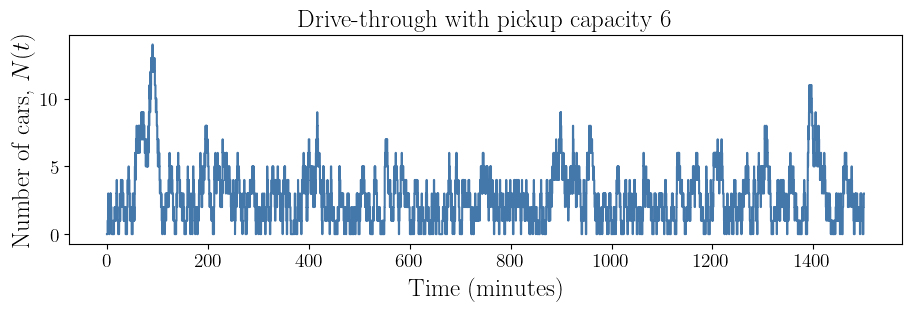

In [6]:
drive_rate = 0.9
drive_horizon = 1500.0
drive_interarrival_times = rng.exponential(1 / drive_rate, 5000)
drive_arrival_times = np.cumsum(drive_interarrival_times)
order_service_times = rng.uniform(0.7, 1.1, len(drive_arrival_times))
pickup_service_times = rng.uniform(0.5, 1.0, len(drive_arrival_times))
assert drive_arrival_times[-1] > drive_horizon
drive = simulate_queue(drive_arrival_times, order_service_times, pickup_service_times,
                       capacity=6, t_end=drive_horizon)
drive_metrics = drive.summary()
show_metrics(drive_metrics, [
    ('arrivals', 'Cars arrived'), ('departures', 'Cars departed'),
    ('remaining', 'Cars still present'), ('avg_N', 'Time-average cars in system'),
    ('avg_wait_1', 'Mean wait before ordering (departed cars)'),
    ('avg_block', 'Mean blocking after ordering (departed cars)'),
    ('avg_wait_2', 'Mean wait in pickup lane (departed cars)'),
    ('avg_W', 'Mean total drive-through time (departed cars)'),
    ('busy_1', 'Order window: fraction serving'),
    ('busy_2', 'Pickup window: fraction serving'),
    ('blocked_1', 'Order window: fraction blocked'),
])
fig, ax = plt.subplots(figsize=(9, 3), constrained_layout=True)
t, number = drive.trajectory()
ax.step(t, number, where='post')
ax.set(xlabel='Time (minutes)', ylabel=r'Number of cars, $N(t)$', title='Drive-through with pickup capacity 6')
plt.show()

### What changes when pickup is slower?

Use the **same arrival epochs and service-duration draws** for each capacity so random input
differences do not obscure the comparison. A larger pickup lane lets the order
window release a car sooner, but does not make pickup itself faster. It may move
waiting from the order window to the pickup lane. Examine blocking, throughput,
and total delay together; a smaller blocking fraction alone does not establish
that the entire system performs better.

<div class="highlight-note"><strong>More space does not mean faster service.</strong> A larger pickup lane can reduce blocking or move waiting downstream without removing the pickup bottleneck.</div>

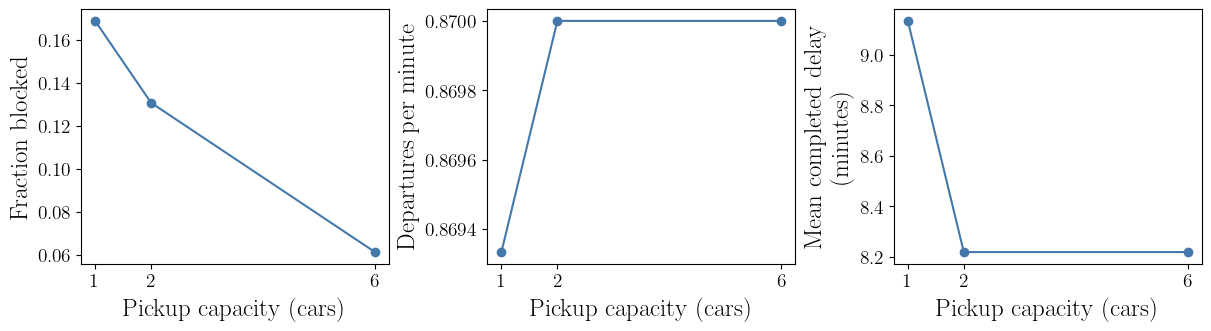

In [7]:
slow_pickup_times = rng.uniform(0.9, 1.3, len(drive_arrival_times))
capacities = [1, 2, 6]
comparison = [simulate_queue(drive_arrival_times, order_service_times, slow_pickup_times,
                            capacity=k, t_end=drive_horizon).summary() for k in capacities]
fig, axes = plt.subplots(1, 3, figsize=(12, 3.2), constrained_layout=True)
for ax, key, label in zip(axes, ['blocked_1', 'throughput', 'avg_W'],
                         ['Fraction blocked', 'Departures per minute', 'Mean completed delay\n(minutes)']):
    ax.plot(capacities, [m[key] for m in comparison], 'o-')
    ax.set(xlabel='Pickup capacity (cars)', ylabel=label, xticks=capacities)
plt.show()
for m in comparison:
    assert 0 <= m['busy_1'] + m['blocked_1'] <= 1 + 1e-12
    assert 0 <= m['busy_2'] <= 1 + 1e-12
    assert m['arrivals'] == m['departures'] + m['remaining']

## What to take away

- **Model the state and events:** residual service times and downstream occupancy matter; queue length alone may not be Markov.
- **Match the summary to the question:** time-average congestion, customer-average delay, service, and blocking measure different things.

### Experiments

1. Increase the single-server arrival rate toward 1. What happens to the
   theoretical waiting time and the simulated paths? What changes when $r>1$?
2. Compare time-limited and departure-limited runs on identical inputs. Which
   customers are excluded from the completed-delay average?
3. Increase the replication horizon. Does the mean completed delay move toward
   the stationary benchmark, and how does variability between runs change?
4. At the drive-through, explain why increasing pickup capacity can reduce
   blocking without removing the pickup bottleneck. Repeat with new input draws.
5. Read the `customer` process in [the helper](../queue_examples.py). Explain
   why releasing the order window before securing a pickup slot would model a
   different physical system.

### Further reading

- [SimPy shared resources](https://simpy.readthedocs.io/en/stable/simpy_intro/shared_resources.html)
- [SimPy simulation control](https://simpy.readthedocs.io/en/stable/topical_guides/environments.html)

The model helper is course-specific. SimPy supplies the event engine; NumPy
supplies random inputs, and `classlib.nbviz` supplies the plotting style.

In [8]:
notebook_elapsed = time.perf_counter() - NOTEBOOK_START_TIME
notebook_minutes, notebook_seconds = divmod(notebook_elapsed, 60)
print(f"Total execution time for this notebook is "
      f"{int(notebook_minutes)} min {notebook_seconds:.1f} sec.")

Total execution time for this notebook is 0 min 5.0 sec.
